Swin-T

In [ ]:
#Local Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import copy
import random
import numpy as np
import pandas as pd

data_dir = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset"

batch_size = 32
num_classes = 500
num_epochs = 20
LR = 1e-4
RUN_ID = 'swin_t_Pre_Full_Aug'

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

Training on device: cuda:0


Data Augmentation: Full

In [ ]:

# Augmented Data
data_transforms_fully_aug = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),    # takes a random patch of the photo and stretches it to 224×224. Half the image is a safer floor for fine-grained work.
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.3, hue=0.03),       # Requires Fine Tuning
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),    # blanks out a random rectangle after the image is a tensor
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms_fully_aug[x]) for x in ['train', 'val']}  # For Full Aug
dataloaders = {x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x == 'train'), num_workers=8, persistent_workers=True, pin_memory=True) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}


model = models.swin_t(weights='DEFAULT')
model.head = nn.Linear(model.head.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
class_names = image_datasets['train'].classes   

0.2%

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to C:\Users\alexs/.cache\torch\hub\checkpoints\swin_t-704ceda3.pth


100.0%


Training

In [3]:


train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_model_wts = copy.deepcopy(model.state_dict())                              # stored weights of the best model
best_acc = 0.0

print("Starting Experiment 4: Swin-T from Pre-Trained Weights (Full Augmentation)")
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()       # Uses current batch statistics
        else:           
            model.eval()        # Uses running averages

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()       # Clears gradients

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)         # 32 Images as Input, 32 x 500 grid, where each image golds the score for all 500 species
                _, preds = torch.max(outputs, 1)    # Minds the maximum score from the 500 row, returns score value and position - position correlates directly to the actual species
                loss = criterion(outputs, labels)

                # Actual physical training
                if phase == 'train':
                    loss.backward()     # Calculates what direction the model should moves to reduce the loss
                    optimizer.step()    # Actualy moves the weights by amount (learning rate)

            running_loss += loss.item() * inputs.size(0)        #average loss for that batch
            running_corrects += torch.sum(preds == labels.data) #Sum of all predictions that were correct

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc)
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc)

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), rf'C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\Swin-T\{RUN_ID}_best.pth')

    print()

    pd.DataFrame({
        'epoch': range(1, len(train_losses) + 1),
        'train_loss': train_losses, 'train_acc': train_accs,
        'val_loss': val_losses, 'val_acc': val_accs,
    }).to_csv(rf'C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\Swin-T\{RUN_ID}_history.csv', index=False)

    scheduler.step()

model.load_state_dict(best_model_wts)

print(f'Experiment 4 Complete. Best Validation Accuracy: {best_acc:.4f}')

Starting Experiment 4: Swin-T from Pre-Trained Weights (Full Augmentation)
Epoch 1/20
----------
Train Loss: 4.1807 Acc: 0.2675
Val Loss: 2.5791 Acc: 0.5560

Epoch 2/20
----------
Train Loss: 2.5041 Acc: 0.6093
Val Loss: 2.1473 Acc: 0.6824

Epoch 3/20
----------
Train Loss: 2.0947 Acc: 0.7208
Val Loss: 2.0277 Acc: 0.7236

Epoch 4/20
----------
Train Loss: 1.8656 Acc: 0.7863
Val Loss: 1.9275 Acc: 0.7574

Epoch 5/20
----------
Train Loss: 1.7153 Acc: 0.8296
Val Loss: 1.8711 Acc: 0.7726

Epoch 6/20
----------
Train Loss: 1.5885 Acc: 0.8676
Val Loss: 1.8351 Acc: 0.7768

Epoch 7/20
----------
Train Loss: 1.5163 Acc: 0.8862
Val Loss: 1.8124 Acc: 0.7860

Epoch 8/20
----------
Train Loss: 1.4333 Acc: 0.9126
Val Loss: 1.7810 Acc: 0.7952

Epoch 9/20
----------
Train Loss: 1.3790 Acc: 0.9268
Val Loss: 1.7597 Acc: 0.7996

Epoch 10/20
----------
Train Loss: 1.3390 Acc: 0.9392
Val Loss: 1.7525 Acc: 0.8002

Epoch 11/20
----------
Train Loss: 1.2966 Acc: 0.9518
Val Loss: 1.7301 Acc: 0.8060

Epoch 12/2

Loss/ Accuracy Curves

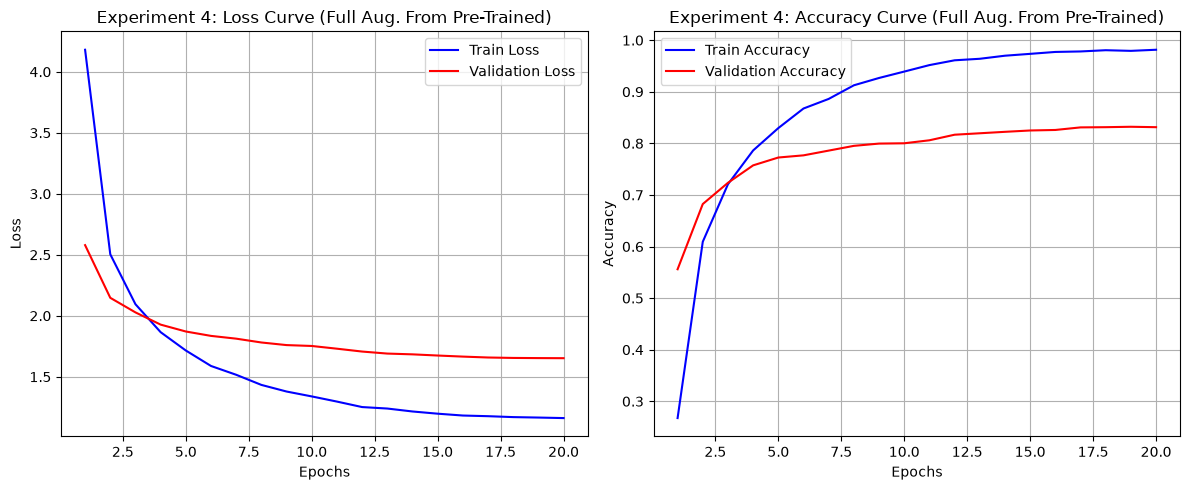

In [ ]:
import matplotlib.pyplot as plt
CKPT = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\Swin-T"
EVAL_SPLIT = 'test' 

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='red')
plt.title('Experiment 4: Loss Curve (Full Aug. From Pre-Trained)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy', color='blue')
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy', color='red')
plt.title('Experiment 4: Accuracy Curve (Full Aug. From Pre-Trained)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_Loss_Accuracy_Curve.png'), dpi=150)
plt.show()

Performance Metric Prep.

In [5]:
import time

CKPT = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\Swin-T"

EVAL_SPLIT = 'test'       

# model.load_state_dict(torch.load(os.path.join(CKPT, 'exp1_scratch_best.pth')))
# model = model.to(device)

eval_ds = datasets.ImageFolder(os.path.join(data_dir, EVAL_SPLIT), data_transforms_fully_aug['val'])
assert eval_ds.classes == image_datasets['train'].classes, "class lists differ!"
eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=2)
class_names = eval_ds.classes

model.eval()
all_top5, all_conf = [], []

if device.type == 'cuda': torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    for inputs, _ in eval_dl:
        probs = model(inputs.to(device)).softmax(1)
        conf, top5 = probs.topk(5, dim=1)
        all_top5.append(top5.cpu())
        all_conf.append(conf[:, 0].cpu())

if device.type == 'cuda': torch.cuda.synchronize()
infer_secs = time.time() - t0

top5 = torch.cat(all_top5).numpy()

df = pd.DataFrame({
    'filepath':   [p for p, _ in eval_ds.samples],
    'true':       [y for _, y in eval_ds.samples],
    'pred':       top5[:, 0],
    'confidence': torch.cat(all_conf).numpy(),
})
for k in range(5):
    df[f'top{k+1}'] = top5[:, k]

df.to_csv(os.path.join(CKPT, f'{RUN_ID}_predictions.csv'), index=False)
print(f'{len(df)} images in {infer_secs:.1f}s  ({infer_secs*1000/len(df):.2f} ms/image)')

5000 images in 12.0s  (2.40 ms/image)


Numerical Performance Metric

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score

df = pd.read_csv(os.path.join(CKPT, f'{RUN_ID}_predictions.csv'))

top1 = (df['pred'] == df['true']).mean()

top5_cols = [f'top{k}' for k in range(1, 6)]
top5_acc = (df[top5_cols].values == df['true'].values[:, None]).any(axis=1).mean()

p, r, f1, _ = precision_recall_fscore_support(
    df['true'], df['pred'], average='macro', zero_division=0)
bal = balanced_accuracy_score(df['true'], df['pred'])

print(f"Top-1 accuracy  : {top1:.4f}")
print(f"Top-5 accuracy  : {top5_acc:.4f}")
print(f"Balanced acc    : {bal:.4f}")
print(f"Macro precision : {p:.4f}")
print(f"Macro recall    : {r:.4f}")
print(f"Macro F1        : {f1:.4f}")

summary_path = os.path.join(r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ResNet50\From Scratch\summary.csv")
pd.DataFrame([{
    'run': RUN_ID, 'arch': 'swin_t', 'augmentation': 'full',
    'epochs': num_epochs, 'top1': top1, 'top5': top5_acc, 'balanced_acc': bal,
    'macro_p': p, 'macro_r': r, 'macro_f1': f1,
    'best_val_acc': best_acc, 'ms_per_img': infer_secs * 1000 / len(df),
}]).to_csv(summary_path, mode='a', header=not os.path.exists(summary_path), index=False)

Top-1 accuracy  : 0.8272
Top-5 accuracy  : 0.9424
Balanced acc    : 0.8272
Macro precision : 0.8383
Macro recall    : 0.8272
Macro F1        : 0.8253


Confusion Matric and Wort Species Pairs

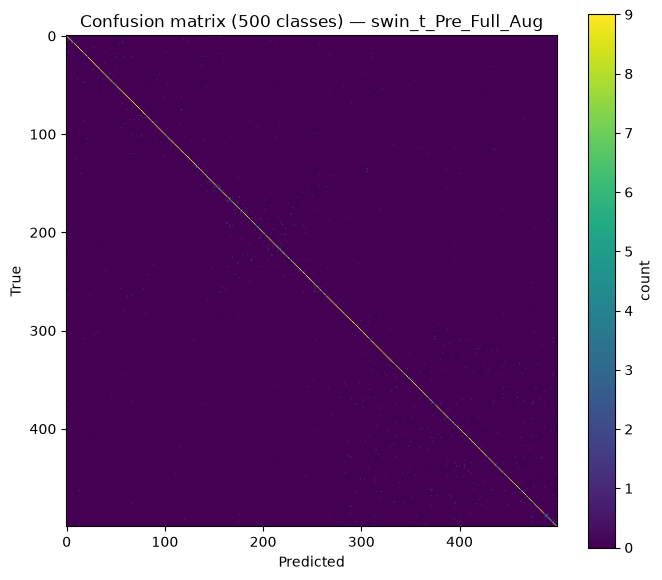


count  true species  →  predicted as
    4  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica  →  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea
    4  09781_Plantae_Tracheophyta_Pinopsida_Pinales_Cupressaceae_Juniperus_deppeana  →  09785_Plantae_Tracheophyta_Pinopsida_Pinales_Cupressaceae_Juniperus_occidentalis
    4  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea  →  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica
    4  09449_Plantae_Tracheophyta_Magnoliopsida_Rosales_Rosaceae_Rosa_majalis  →  09452_Plantae_Tracheophyta_Magnoliopsida_Rosales_Rosaceae_Rosa_palustris
    4  03755_Animalia_Chordata_Aves_Passeriformes_Corvidae_Corvus_frugilegus  →  03759_Animalia_Chordata_Aves_Passeriformes_Corvidae_Corvus_ossifragus
    4  02534_Animalia_Arthropoda_Insecta_Odonata_Libellulidae_Orthetrum_cancellatum  →  02532_Animalia_Arthropoda_Insecta_Odonata_Libellulidae_

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['true'], df['pred'], labels=range(num_classes))

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='viridis', vmax=np.percentile(cm, 99.9))
plt.colorbar(label='count')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion matrix ({num_classes} classes) — {RUN_ID}')
plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_confusion.png'), dpi=150)
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
rows, cols = np.unravel_index(np.argsort(off, axis=None)[::-1][:15], off.shape)

print("\ncount  true species  →  predicted as")
for a, b in zip(rows, cols):
    print(f"{off[a,b]:5d}  {class_names[a]}  →  {class_names[b]}")

Per-Class F1 and Failure Examples

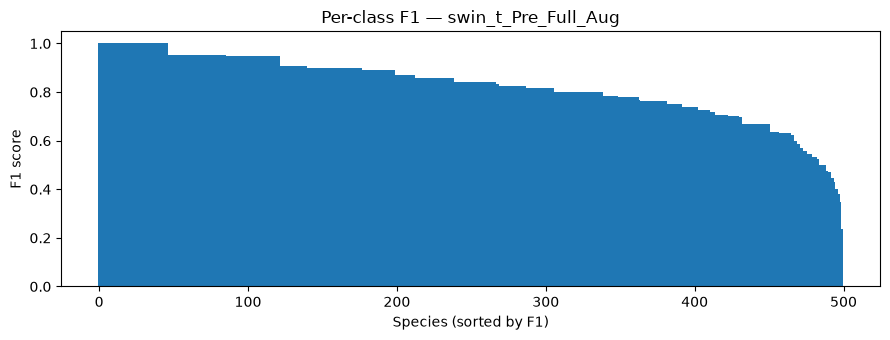

Species never correctly identified: 0 / 500

Most confident mistakes:
0.97  09154_Plantae_Tracheophyta_Magnoliopsida_Ranunculales_Berberidaceae_Podophyllum_peltatum  called  06127_Plantae_Tracheophyta_Liliopsida_Liliales_Colchicaceae_Uvularia_grandiflora
      C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset\test\09154_Plantae_Tracheophyta_Magnoliopsida_Ranunculales_Berberidaceae_Podophyllum_peltatum\8a5328a3-2376-43d6-9bc4-de5696b0c367.jpg
0.97  03270_Animalia_Chordata_Aves_Anseriformes_Anatidae_Spatula_discors  called  04475_Animalia_Chordata_Aves_Podicipediformes_Podicipedidae_Podiceps_auritus
      C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset\test\03270_Animalia_Chordata_Aves_Anseriformes_Anatidae_Spatula_discors\2cb585ae-d122-4a04-b680-4b1b964cdd87.jpg
0.96  03759_Animalia_Chordata_Aves_Passeriformes_Corvidae_Corvus_ossifragus  called  03755_Animalia_Chordata_Aves_Passeriformes_Corvidae_Corvus_frug

In [8]:
_, _, f1_per, _ = precision_recall_fscore_support(
    df['true'], df['pred'], average=None, labels=range(num_classes), zero_division=0)

plt.figure(figsize=(9, 3.5))
plt.bar(range(num_classes), np.sort(f1_per)[::-1], width=1.0)
plt.xlabel('Species (sorted by F1)'); plt.ylabel('F1 score')
plt.title(f'Per-class F1 — {RUN_ID}')
plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_perclass_f1.png'), dpi=150)
plt.show()

print(f"Species never correctly identified: {(f1_per == 0).sum()} / {num_classes}")

print("\nMost confident mistakes:")
for _, row in df[df.pred != df.true].nlargest(10, 'confidence').iterrows():
    print(f"{row.confidence:.2f}  {class_names[row.true]}  called  {class_names[row.pred]}")
    print(f"      {row.filepath}")